<a href="https://colab.research.google.com/github/karthikoo7/Machine_Learning-BDA-/blob/main/TimeSeries_ARIMA_SARIMA_TIMESERIES_AS_REgression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [102]:
import pandas as pd

# parse_dates parameter to convert column type to datetime type

In [103]:
df = pd.read_csv('Coal Consumption.csv',parse_dates=['Month'])
df.shape

(132, 4)

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Month          132 non-null    datetime64[ns]
 1   Amount         132 non-null    float64       
 2   Extract_month  132 non-null    int64         
 3   Extract Year   132 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 4.3 KB


In [105]:
df.set_index('Month',inplace=True)

In [106]:
df.head()


,Amount,Extract_month,Extract Year
Month,,,
1990-01-01,16.50,1,1990
1990-02-01,15.17,2,1990
1990-03-01,12.75,3,1990
1990-04-01,12.31,4,1990
1990-05-01,8.34,5,1990


In [107]:
df.loc["1990"]

,Amount,Extract_month,Extract Year
Month,,,
1990-01-01,16.50,1,1990
1990-02-01,15.17,2,1990
1990-03-01,12.75,3,1990
1990-04-01,12.31,4,1990
1990-05-01,8.34,5,1990
1990-06-01,8.63,6,1990
1990-07-01,12.37,7,1990
1990-08-01,11.53,8,1990
1990-09-01,9.47,9,1990


In [108]:
df.loc["01-1990"]

,Amount,Extract_month,Extract Year
Month,,,
1990-01-01,16.5,1,1990


In [109]:
df.loc["01-1990":"05-1990"] # last term included here while slicing ...? why -- Cuz, Label Based

,Amount,Extract_month,Extract Year
Month,,,
1990-01-01,16.50,1,1990
1990-02-01,15.17,2,1990
1990-03-01,12.75,3,1990
1990-04-01,12.31,4,1990
1990-05-01,8.34,5,1990


# Check the missing values

1. check the frequency of the data

2. Use as frequency function from pandas


https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases

In [110]:
df.isnull().sum() # not the best way to check missing values in a TIme Series

,0
Amount,0
Extract_month,0
Extract Year,0


In [111]:
df1 = df.asfreq("MS")
df1.shape,df.shape

# utlize asfreq() fn

((132, 3), (132, 3))

# Fill missing values (we Use)
--
back fill(bfill)
fill the next day value in current day
ex fill 20th june value in 19th june record
--
front fill (ffil)
fill the previous value in current value
ex fill 18th june value in 19th june record
--


In [112]:
df.fillna(method="ffill",inplace=True)

/tmp/ipykernel_4149/1844562654.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill",inplace=True)


# Time Series decomposition

# possible errors
this decompose fn may give error in 3 cases
1.when data is not pandas dataframe
2. when index of the dataframe is not time
3.there are missing values in the time series

# note: when we get error here chekc above 3 options before applying any other solution  

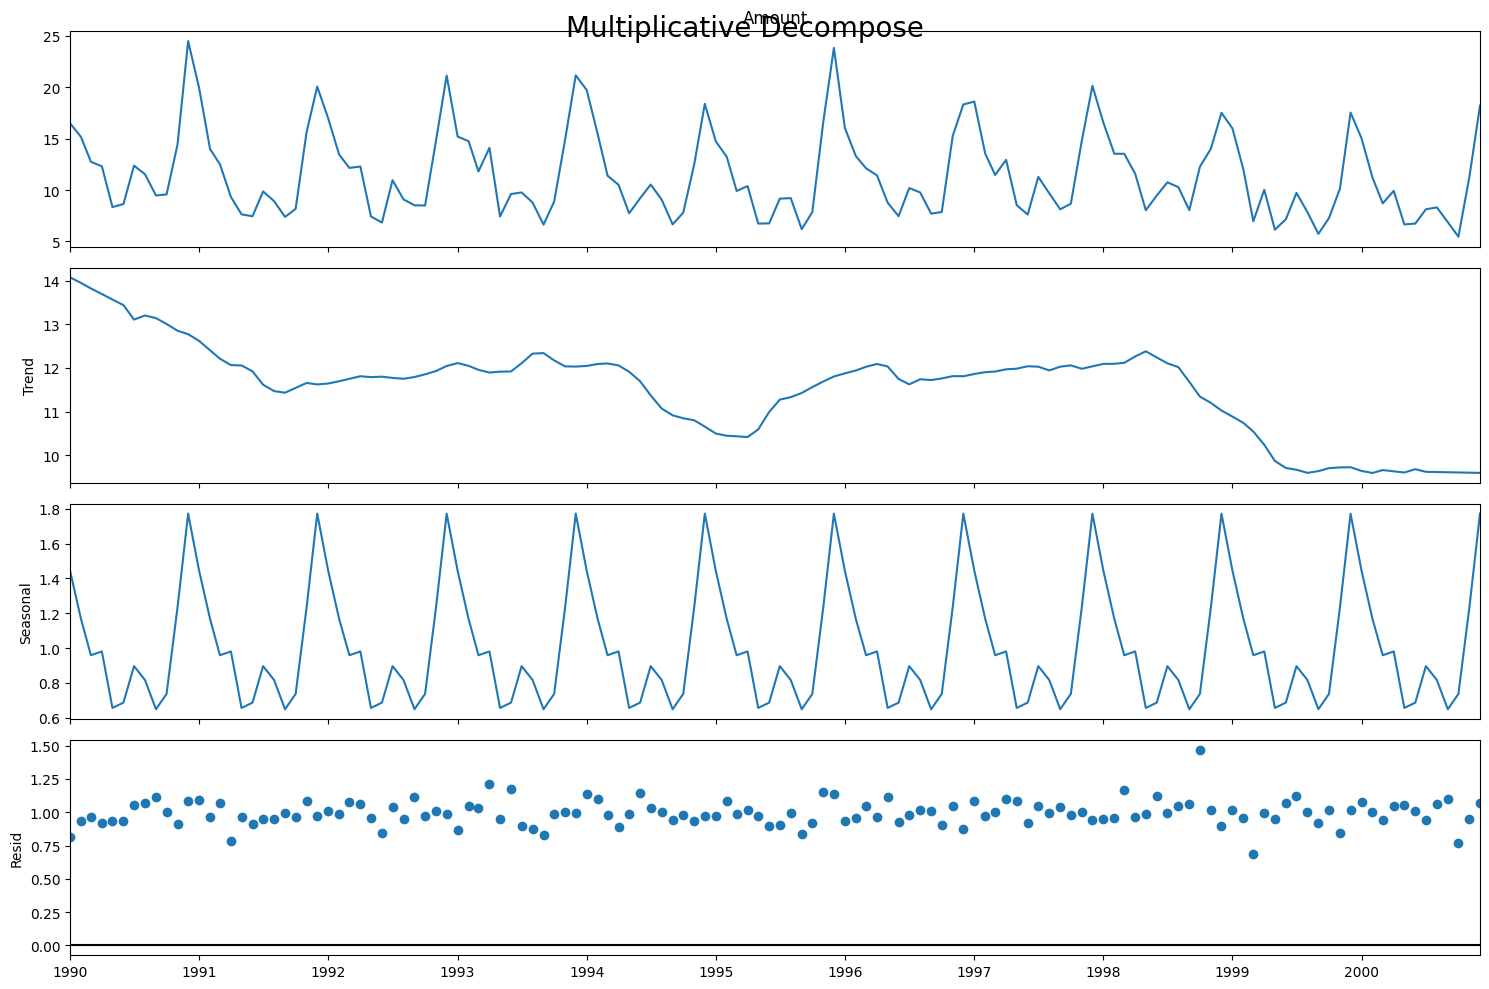

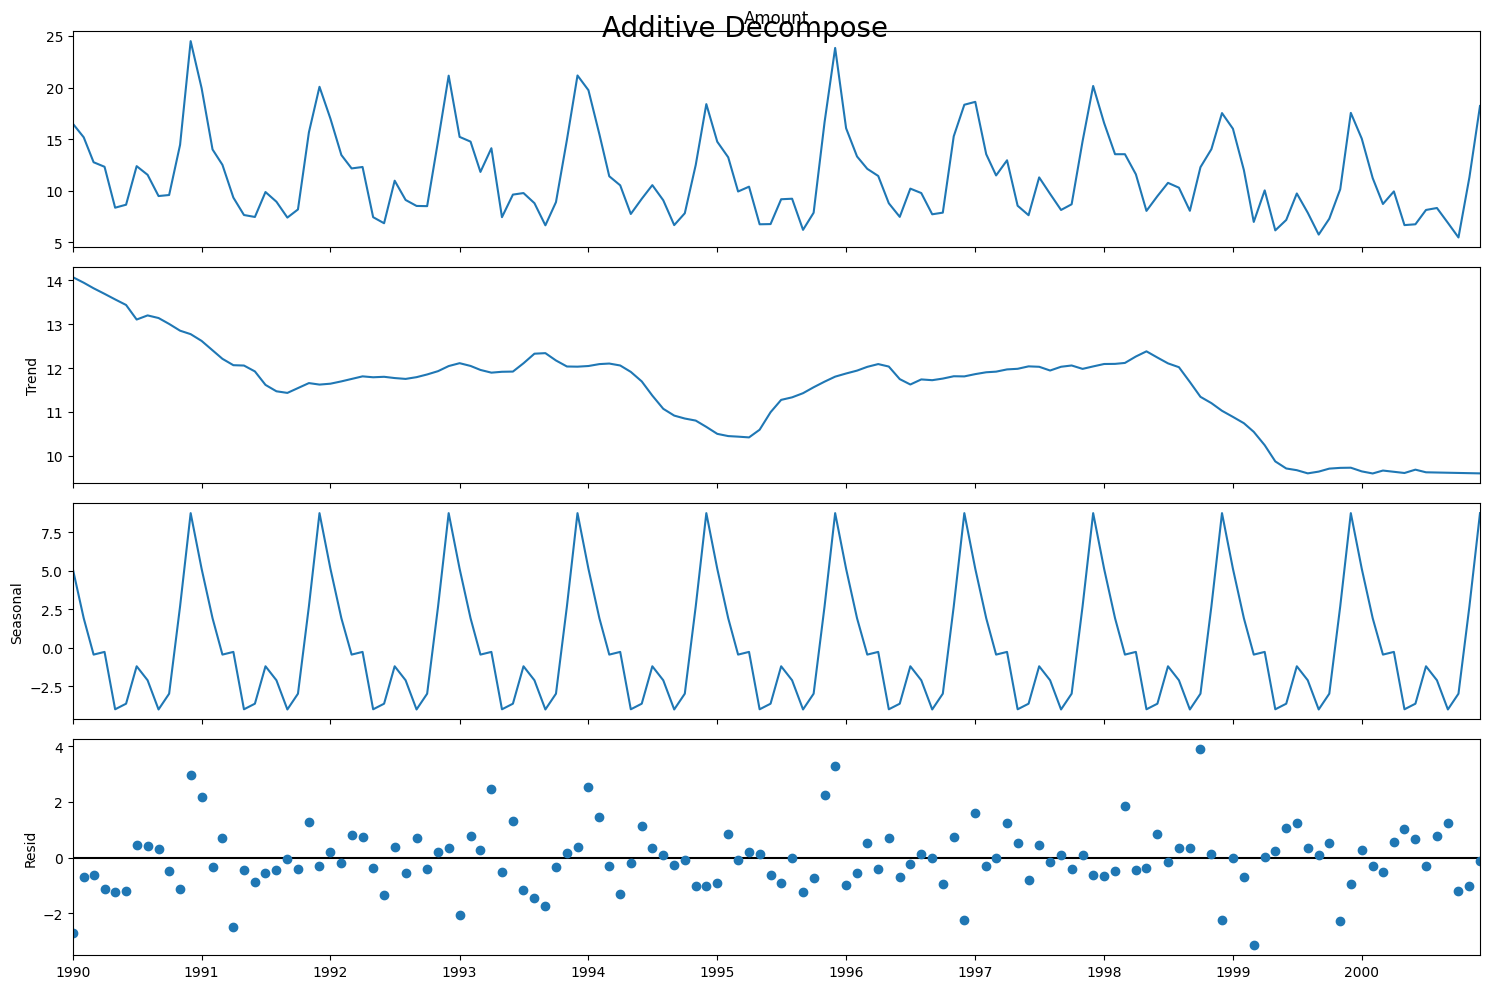

In [113]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from dateutil.parser import parse

# Multiplicative Decomposition
result_mul = seasonal_decompose(df['Amount'], model='multiplicative', extrapolate_trend='freq')

# Additive Decomposition
result_add = seasonal_decompose(df['Amount'], model='additive', extrapolate_trend='freq')

# Plot
plt.rcParams.update({'figure.figsize': (15,10)})
result_mul.plot().suptitle('Multiplicative Decompose', fontsize=20)
result_add.plot().suptitle('Additive Decompose', fontsize=20)
plt.show()

# how do we decide on the basis of decompose whether model is additive or multiplicative.

--> we observe residue of both the plots.
--> residues should be completly random without any patterns.
--> Additive  --> we may observe some pattern in the residue.
--> Multiplicative --> random residue

# Check the stationarity of time series

In [114]:
from statsmodels.tsa.stattools import adfuller
import random
random.seed(7)
# ADF Test
#Augmented Dickey–Fuller test
result = adfuller(df['Amount'].values, autolag='AIC')
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
for key, value in result[4].items():
    print('Critial Values:')
    print(f'   {key}, {value}')

ADF Statistic: -1.7135083213470805
p-value: 0.42416636643258177
Critial Values:
   1%, -3.4870216863700767
Critial Values:
   5%, -2.8863625166643136
Critial Values:
   10%, -2.580009026141913


# ADF Test COnclusion:
p-value > 0.05, Fail to Reject Null Hypothesis --> Data is not stationary(TIme series is not stationary) -- we need to make it stationary  

In [115]:
df['lag1'] = df['Amount'].shift(1)

In [116]:
df.head()

,Amount,Extract_month,Extract Year,lag1
Month,,,,
1990-01-01,16.50,1,1990,NaN
1990-02-01,15.17,2,1990,16.50
1990-03-01,12.75,3,1990,15.17
1990-04-01,12.31,4,1990,12.75
1990-05-01,8.34,5,1990,12.31


In [117]:
df['st'] = df['Amount'] - df['lag1']

In [118]:
df.head()

,Amount,Extract_month,Extract Year,lag1,st
Month,,,,,
1990-01-01,16.50,1,1990,NaN,NaN
1990-02-01,15.17,2,1990,16.50,-1.33
1990-03-01,12.75,3,1990,15.17,-2.42
1990-04-01,12.31,4,1990,12.75,-0.44
1990-05-01,8.34,5,1990,12.31,-3.97


In [119]:
from statsmodels.tsa.stattools import adfuller
import random
random.seed(7)
# ADF Test
#Augmented Dickey–Fuller test
result = adfuller(df['st'].values[1:], autolag='AIC')
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
for key, value in result[4].items():
    print('Critial Values:')
    print(f'   {key}, {value}')

ADF Statistic: -3.902725577236599
p-value: 0.002014879672496045
Critial Values:
   1%, -3.487517288664615
Critial Values:
   5%, -2.8865777180380032
Critial Values:
   10%, -2.5801239192052012


ADF Conclusion (Stationarity Test):

Reject Null Hypothesis.(time series data in 'st' column is stationary)


# Apply Time Series Models

Use pmdarima for ARIMA and sarima

In [120]:
!pip install pmdarima


In [121]:
import pmdarima as pm
from pmdarima.model_selection import train_test_split

In [122]:
y = df['Amount']

In [123]:
y.shape

(132,)

In [124]:
train,test = train_test_split(y,train_size=0.7)
train.shape,test.shape

((92,), (40,))

In [125]:
# Fit your model -- SARIMA (p,d,q) (P,D,Q) m & ARIMA(p,d,q)
# auto_arima to automatically get the best values for p,d,q for ARIMA and SARIMA models


In [126]:
# Fit your model -- SARIMA (Seasonlity here --)
model = pm.auto_arima( train, start_p=5,max_p = 20, start_q=2,max_q=20, seasonal=True, trace = True,m=6, random_state=7) #seasonal =False

# check for minimum AIC values for best score


Performing stepwise search to minimize aic
 ARIMA(5,0,2)(1,0,1)[6] intercept   : AIC=394.606, Time=1.75 sec
 ARIMA(0,0,0)(0,0,0)[6] intercept   : AIC=527.476, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[6] intercept   : AIC=474.251, Time=0.36 sec
 ARIMA(0,0,1)(0,0,1)[6] intercept   : AIC=476.371, Time=0.19 sec
 ARIMA(0,0,0)(0,0,0)[6]             : AIC=728.231, Time=0.04 sec
 ARIMA(5,0,2)(0,0,1)[6] intercept   : AIC=456.694, Time=1.20 sec
 ARIMA(5,0,2)(1,0,0)[6] intercept   : AIC=409.569, Time=5.29 sec
 ARIMA(5,0,2)(2,0,1)[6] intercept   : AIC=inf, Time=4.58 sec
 ARIMA(5,0,2)(1,0,2)[6] intercept   : AIC=412.953, Time=9.68 sec
 ARIMA(5,0,2)(0,0,0)[6] intercept   : AIC=452.518, Time=3.18 sec
 ARIMA(5,0,2)(0,0,2)[6] intercept   : AIC=428.895, Time=3.57 sec
 ARIMA(5,0,2)(2,0,0)[6] intercept   : AIC=396.886, Time=4.93 sec
 ARIMA(5,0,2)(2,0,2)[6] intercept   : AIC=379.033, Time=1.64 sec
 ARIMA(4,0,2)(2,0,2)[6] intercept   : AIC=378.257, Time=1.32 sec
 ARIMA(4,0,2)(1,0,2)[6] intercept   : AIC=415.870, 

In [127]:
# Fit your model -- ARIMA ( No Seasonlity) (removed m paramter)
model = pm.auto_arima( train, start_p=5,max_p = 20, start_q=2,max_q=20, seasonal=False, trace = True, random_state=7) #seasonal =False

# check for minimum AIC values for best score


Performing stepwise search to minimize aic
 ARIMA(5,0,2)(0,0,0)[0]             : AIC=483.922, Time=2.00 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=728.231, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=501.905, Time=0.07 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=633.168, Time=0.08 sec
 ARIMA(4,0,2)(0,0,0)[0]             : AIC=481.990, Time=0.92 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=480.126, Time=0.38 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.29 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=inf, Time=0.26 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=inf, Time=0.39 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=499.300, Time=0.08 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=0.37 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=494.520, Time=0.11 sec
 ARIMA(4,0,3)(0,0,0)[0]             : AIC=483.405, Time=0.43 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=471.700, Time=0.32 sec
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=467.863, Time=0.32 se

# Set value for d

In [128]:
# Fit your model -- SARIMA (Seasonlity here --) (added d=1 --> lag value)
model = pm.auto_arima( train,d=1, start_p=5,max_p = 20, start_q=2,max_q=20, seasonal=True, trace = True,m=6, random_state=7) #seasonal =False

# check for minimum AIC values for best score


Performing stepwise search to minimize aic
 ARIMA(5,1,2)(1,0,1)[6] intercept   : AIC=381.241, Time=0.95 sec
 ARIMA(0,1,0)(0,0,0)[6] intercept   : AIC=495.719, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[6] intercept   : AIC=489.762, Time=0.08 sec
 ARIMA(0,1,1)(0,0,1)[6] intercept   : AIC=491.739, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[6]             : AIC=493.758, Time=0.03 sec
 ARIMA(5,1,2)(0,0,1)[6] intercept   : AIC=inf, Time=0.77 sec
 ARIMA(5,1,2)(1,0,0)[6] intercept   : AIC=391.613, Time=0.84 sec
 ARIMA(5,1,2)(2,0,1)[6] intercept   : AIC=inf, Time=1.58 sec
 ARIMA(5,1,2)(1,0,2)[6] intercept   : AIC=364.028, Time=3.18 sec
 ARIMA(5,1,2)(0,0,2)[6] intercept   : AIC=inf, Time=1.57 sec
 ARIMA(5,1,2)(2,0,2)[6] intercept   : AIC=inf, Time=1.61 sec
 ARIMA(4,1,2)(1,0,2)[6] intercept   : AIC=inf, Time=1.03 sec
 ARIMA(5,1,1)(1,0,2)[6] intercept   : AIC=inf, Time=1.21 sec
 ARIMA(5,1,3)(1,0,2)[6] intercept   : AIC=inf, Time=1.40 sec
 ARIMA(4,1,1)(1,0,2)[6] intercept   : AIC=inf, Time=1.04 sec
 ARIMA(4,1,3)(

In [129]:
# Fit your model -- ARIMA ( No Seasonlity) (removed m paramter) (added d=1,lag value --> differencing)
model = pm.auto_arima( train, d=1,start_p=5,max_p = 20, start_q=2,max_q=20, seasonal=False, trace = True, random_state=7) #seasonal =False

# check for minimum AIC values for best score


Performing stepwise search to minimize aic
 ARIMA(5,1,2)(0,0,0)[0] intercept   : AIC=447.907, Time=0.54 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=495.719, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=495.044, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=492.581, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=493.758, Time=0.02 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=1.48 sec
 ARIMA(5,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=1.95 sec
 ARIMA(6,1,2)(0,0,0)[0] intercept   : AIC=450.591, Time=0.79 sec
 ARIMA(5,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.69 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=489.479, Time=0.17 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.63 sec
 ARIMA(6,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.60 sec
 ARIMA(6,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.72 sec
 ARIMA(5,1,2)(0,0,0)[0]             : AIC=444.319, Time=0.59 sec
 ARIMA(4,1,2)(0,0,0)[0]             : AIC=inf, Time=0.40 sec
 ARIMA(5,1

# Now performing the above excercise using df['st'] column -- is stationary

In [130]:
y = df['st'][1:]

In [131]:
train,test = train_test_split(y,train_size=0.7)
train.shape,test.shape

((91,), (40,))

In [132]:
# Fit your model -- SARIMA (Seasonlity here --)
model = pm.auto_arima( train, start_p=5,max_p = 20, start_q=2,max_q=20, seasonal=True, trace = True,m=6, random_state=7) #seasonal =False

# check for minimum AIC values for best score


Performing stepwise search to minimize aic
 ARIMA(5,0,2)(1,0,1)[6] intercept   : AIC=380.234, Time=0.95 sec
 ARIMA(0,0,0)(0,0,0)[6] intercept   : AIC=495.719, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[6] intercept   : AIC=489.762, Time=0.07 sec
 ARIMA(0,0,1)(0,0,1)[6] intercept   : AIC=491.739, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[6]             : AIC=493.758, Time=0.02 sec
 ARIMA(5,0,2)(0,0,1)[6] intercept   : AIC=inf, Time=0.72 sec
 ARIMA(5,0,2)(1,0,0)[6] intercept   : AIC=391.613, Time=2.58 sec
 ARIMA(5,0,2)(2,0,1)[6] intercept   : AIC=inf, Time=2.04 sec
 ARIMA(5,0,2)(1,0,2)[6] intercept   : AIC=inf, Time=1.42 sec
 ARIMA(5,0,2)(0,0,0)[6] intercept   : AIC=448.116, Time=0.49 sec
 ARIMA(5,0,2)(0,0,2)[6] intercept   : AIC=inf, Time=0.97 sec
 ARIMA(5,0,2)(2,0,0)[6] intercept   : AIC=inf, Time=1.16 sec
 ARIMA(5,0,2)(2,0,2)[6] intercept   : AIC=inf, Time=1.65 sec
 ARIMA(4,0,2)(1,0,1)[6] intercept   : AIC=inf, Time=0.73 sec
 ARIMA(5,0,1)(1,0,1)[6] intercept   : AIC=375.549, Time=1.56 sec
 ARIMA(5,0

In [133]:
# Fit your model -- ARIMA ( No Seasonlity) (removed m paramter)
model = pm.auto_arima( train, start_p=5,max_p = 20, start_q=2,max_q=20, seasonal=False, trace = True, random_state=7) #seasonal =False

# check for minimum AIC values for best score


Performing stepwise search to minimize aic
 ARIMA(5,0,2)(0,0,0)[0]             : AIC=443.996, Time=0.55 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=493.758, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=493.077, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=490.613, Time=0.03 sec
 ARIMA(4,0,2)(0,0,0)[0]             : AIC=inf, Time=0.35 sec
 ARIMA(5,0,1)(0,0,0)[0]             : AIC=inf, Time=0.43 sec
 ARIMA(6,0,2)(0,0,0)[0]             : AIC=448.576, Time=0.55 sec
 ARIMA(5,0,3)(0,0,0)[0]             : AIC=inf, Time=0.56 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=487.553, Time=0.08 sec
 ARIMA(4,0,3)(0,0,0)[0]             : AIC=inf, Time=0.45 sec
 ARIMA(6,0,1)(0,0,0)[0]             : AIC=inf, Time=0.50 sec
 ARIMA(6,0,3)(0,0,0)[0]             : AIC=inf, Time=0.54 sec
 ARIMA(5,0,2)(0,0,0)[0] intercept   : AIC=448.116, Time=0.53 sec

Best model:  ARIMA(5,0,2)(0,0,0)[0]          
Total fit time: 4.622 seconds


In [134]:
# Fit your model -- SARIMA (Seasonlity here --) (added d=1 --> lag value)
model = pm.auto_arima( train,d=1, start_p=5,max_p = 20, start_q=2,max_q=20, seasonal=True, trace = True,m=6, random_state=7) #seasonal =False

# check for minimum AIC values for best score


Performing stepwise search to minimize aic
 ARIMA(5,1,2)(1,0,1)[6] intercept   : AIC=inf, Time=0.93 sec
 ARIMA(0,1,0)(0,0,0)[6] intercept   : AIC=536.654, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[6] intercept   : AIC=529.076, Time=0.07 sec
 ARIMA(0,1,1)(0,0,1)[6] intercept   : AIC=inf, Time=0.27 sec
 ARIMA(0,1,0)(0,0,0)[6]             : AIC=534.654, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[6] intercept   : AIC=534.191, Time=0.05 sec
 ARIMA(1,1,0)(2,0,0)[6] intercept   : AIC=462.161, Time=0.16 sec
 ARIMA(1,1,0)(2,0,1)[6] intercept   : AIC=464.152, Time=0.23 sec
 ARIMA(1,1,0)(1,0,1)[6] intercept   : AIC=inf, Time=0.38 sec
 ARIMA(0,1,0)(2,0,0)[6] intercept   : AIC=495.388, Time=0.08 sec
 ARIMA(2,1,0)(2,0,0)[6] intercept   : AIC=454.025, Time=0.20 sec
 ARIMA(2,1,0)(1,0,0)[6] intercept   : AIC=523.934, Time=0.19 sec
 ARIMA(2,1,0)(2,0,1)[6] intercept   : AIC=inf, Time=2.72 sec
 ARIMA(2,1,0)(1,0,1)[6] intercept   : AIC=inf, Time=0.86 sec
 ARIMA(3,1,0)(2,0,0)[6] intercept   : AIC=445.702, Time=0.28 sec
 A

In [135]:
# Fit your model -- ARIMA ( No Seasonlity) (removed m paramter) (added d=1,lag value --> differencing)
model = pm.auto_arima( train, d=1,start_p=5,max_p = 20, start_q=2,max_q=20, seasonal=False, trace = True, random_state=7) #seasonal =False

# check for minimum AIC values for best score


Performing stepwise search to minimize aic
 ARIMA(5,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.49 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=536.654, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=534.191, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.18 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=534.654, Time=0.03 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=522.832, Time=0.06 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=506.688, Time=0.08 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=508.412, Time=0.12 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.32 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.29 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.51 sec
 ARIMA(3,1,0)(0,0,0)[0]             : AIC=504.691, Time=0.05 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=520.833, Time=0.04 sec
 ARIMA(4,1,0)(0,0,0)[0]             : AIC=506.416, Time=0.07 sec
 ARIMA(3,1,1)(0,0,0)[0]             : AIC=inf, Time=0.23 sec
 ARIMA

In [136]:
from pmdarima.arima import ARIMA

# ARIMA Model


In [137]:
ar = ARIMA((5,0,2),with_intercept=False)
ar.fit(train)
forecast = ar.predict(test.shape[0])

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optim

In [138]:
pd.DataFrame([test,forecast])

,1997-09-01,1997-10-01,1997-11-01,1997-12-01,1998-01-01,1998-02-01,1998-03-01,1998-04-01,1998-05-01,1998-06-01,...,2000-03-01,2000-04-01,2000-05-01,2000-06-01,2000-07-01,2000-08-01,2000-09-01,2000-10-01,2000-11-01,2000-12-01
st,-1.56000,0.550000,6.120000,5.360000,-3.590000,-3.030000,0.000000,-1.950000,-3.550000,1.430000,...,-2.51000,1.22000,-3.270000,0.080000,1.390000,0.190000,-1.440000,-1.420000,5.840000,6.920000
Unnamed 0,-0.12206,2.061774,3.987536,1.736878,-0.551283,-1.262339,-0.883276,-1.382587,-2.216357,-2.021778,...,-1.01733,-1.61511,-1.772507,-1.455921,-0.773074,0.089003,0.917099,1.505363,1.698661,1.444598


In [139]:
from sklearn.metrics import root_mean_squared_error,mean_absolute_error

print('root_mean_squared_error',root_mean_squared_error(test,forecast))
print('mean_absolute_error',mean_absolute_error(test,forecast))

root_mean_squared_error 2.793638879143346
mean_absolute_error 2.4372314229920518


SARIMA Model
--
remember to give seasonal order for SARIMA Model

In [140]:
ar = ARIMA((5,0,0),(1,0,1,6),with_intercept=True)
ar.fit(train)
forecast = ar.predict(test.shape[0])

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [141]:
pd.DataFrame([test,forecast])

,1997-09-01,1997-10-01,1997-11-01,1997-12-01,1998-01-01,1998-02-01,1998-03-01,1998-04-01,1998-05-01,1998-06-01,...,2000-03-01,2000-04-01,2000-05-01,2000-06-01,2000-07-01,2000-08-01,2000-09-01,2000-10-01,2000-11-01,2000-12-01
st,-1.56000,0.550000,6.120000,5.360000,-3.590000,-3.030000,0.000000,-1.950000,-3.550000,1.430000,...,-2.510000,1.220000,-3.270000,0.080000,1.390000,0.190000,-1.44000,-1.420000,5.840000,6.92000
Unnamed 0,-1.30217,0.835217,6.719794,4.426517,-3.135985,-2.825267,-1.499861,-0.244447,-3.819125,-1.655556,...,-0.757405,-0.361223,-4.604571,-2.371523,3.020002,0.587697,-0.25677,0.473021,5.651436,3.27555


In [142]:
from sklearn.metrics import root_mean_squared_error,mean_absolute_error

print('root_mean_squared_error',root_mean_squared_error(test,forecast))
print('mean_absolute_error',mean_absolute_error(test,forecast))

root_mean_squared_error 2.0691924358059297
mean_absolute_error 1.6649781131967845


# Time Series As Regression of Lag Values

-- r2 score not valid as an evaluation metric here -- dealing with time series

## Work with non-stationary 'Amount' column
-- Linear Regression
-- Polynomial features (degree 2) + Linear Regression
-- Polynomial features (degree 2) + Lasso
-- Polynomial features (degree 2) + Ridge

In [143]:
df['lag2'] = df['Amount'].shift(2)
df['lag3'] = df['Amount'].shift(3)
df['lag4'] = df['Amount'].shift(4)
df['lag5'] = df['Amount'].shift(5)
df['lag6'] = df['Amount'].shift(6)

In [144]:
df.head()

,Amount,Extract_month,Extract Year,lag1,st,lag2,lag3,lag4,lag5,lag6
Month,,,,,,,,,,
1990-01-01,16.50,1,1990,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-02-01,15.17,2,1990,16.50,-1.33,NaN,NaN,NaN,NaN,NaN
1990-03-01,12.75,3,1990,15.17,-2.42,16.50,NaN,NaN,NaN,NaN
1990-04-01,12.31,4,1990,12.75,-0.44,15.17,16.50,NaN,NaN,NaN
1990-05-01,8.34,5,1990,12.31,-3.97,12.75,15.17,16.5,NaN,NaN


In [145]:
df.dropna(inplace=True)
df.shape

(126, 10)

In [146]:
# X --> All lag columns
# Y --> Amount Columns
# Converting time series problem into a regression problem (stored sequence in/as lag values) (all sequence stored in a row ..i.e prev 6 values here)

X = df[['lag1','lag2','lag3','lag4','lag5','lag6']]
Y=df['Amount']
X.shape,Y.shape

((126, 6), (126,))

In [147]:
df.isna().sum()

,0
Amount,0
Extract_month,0
Extract Year,0
lag1,0
st,0
lag2,0
lag3,0
lag4,0
lag5,0
lag6,0


In [148]:
from sklearn.model_selection import train_test_split

In [149]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.3,random_state=7)
X_train.shape,X_test.shape,Y_train.shape,Y_test.shape

((88, 6), (38, 6), (88,), (38,))

In [150]:
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.preprocessing import PolynomialFeatures

lr = LinearRegression()
lr.fit(X_train,Y_train)
y_pred = lr.predict(X_test)


print('root_mean_squared_error',root_mean_squared_error(Y_test,y_pred))
print('mean_absolute_error',mean_absolute_error(Y_test,y_pred))

root_mean_squared_error 3.0405584465668274
mean_absolute_error 2.3142176174811304


In [151]:
# using Polynomial features
pf = PolynomialFeatures(degree=2)
X_train_pf = pf.fit_transform(X_train)
X_test_pf = pf.transform(X_test)


lr = LinearRegression()
lr.fit(X_train_pf,Y_train)
y_pred = lr.predict(X_test_pf)


print('root_mean_squared_error',root_mean_squared_error(Y_test,y_pred))
print('mean_absolute_error',mean_absolute_error(Y_test,y_pred))

root_mean_squared_error 2.7130374407941744
mean_absolute_error 1.9617420853363234


In [152]:
# Adding L1 penalty
ls = Lasso(alpha=1,random_state=7)
ls.fit(X_train_pf,Y_train)
y_pred = ls.predict(X_test_pf)

print('root_mean_squared_error: ',root_mean_squared_error(Y_test,y_pred))
print('mean_absolute_error: ',mean_absolute_error(Y_test,y_pred))

root_mean_squared_error:  3.1214303905082263
mean_absolute_error:  2.293684248203563


In [153]:
# Adding L2 Penalty
rg = Ridge(alpha=1,random_state=7)
rg.fit(X_train_pf,Y_train)
y_pred = rg.predict(X_test_pf)

print('root_mean_squared_error: ',root_mean_squared_error(Y_test,y_pred))
print('mean_absolute_error: ',mean_absolute_error(Y_test,y_pred))


root_mean_squared_error:  2.722467565282643
mean_absolute_error:  1.9901058619844612


## Work with stationary 'st' column
-- Linear Regression
-- Polynomial features (degree 2) + Linear Regression
-- Polynomial features (degree 2) + Lasso
-- Polynomial features (degree 2) + Ridge

In [164]:
df['lag1_st'] = df['st'].shift(1)
df['lag2_st'] = df['st'].shift(2)
df['lag3_st'] = df['st'].shift(3)
df['lag4_st'] = df['st'].shift(4)
df['lag5_st'] = df['st'].shift(5)
df['lag6_st'] = df['st'].shift(6)

In [165]:
df.head()

,Amount,Extract_month,Extract Year,lag1,st,lag2,lag3,lag4,lag5,lag6,lag1_st,lag2_st,lag3_st,lag4_st,lag5_st,lag6_st
Month,,,,,,,,,,,,,,,,
1991-01-01,19.94,1,1991,24.50,-4.56,14.44,9.57,9.47,11.53,12.37,NaN,NaN,NaN,NaN,NaN,NaN
1991-02-01,13.99,2,1991,19.94,-5.95,24.50,14.44,9.57,9.47,11.53,-4.56,NaN,NaN,NaN,NaN,NaN
1991-03-01,12.50,3,1991,13.99,-1.49,19.94,24.50,14.44,9.57,9.47,-5.95,-4.56,NaN,NaN,NaN,NaN
1991-04-01,9.32,4,1991,12.50,-3.18,13.99,19.94,24.50,14.44,9.57,-1.49,-5.95,-4.56,NaN,NaN,NaN
1991-05-01,7.63,5,1991,9.32,-1.69,12.50,13.99,19.94,24.50,14.44,-3.18,-1.49,-5.95,-4.56,NaN,NaN


In [166]:
df.dropna(inplace=True)
df.shape

(114, 16)

In [167]:
# X --> All lag columns
# Y --> Amount Columns
# Converting time series problem into a regression problem (stored sequence in/as lag values) (all sequence stored in a row ..i.e prev 6 values here)

X = df[['lag1_st','lag2_st','lag3_st','lag4_st','lag5_st','lag6_st']]
Y=df['st']
X.shape,Y.shape

((114, 6), (114,))

In [168]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.3,random_state=7)
X_train.shape,X_test.shape,Y_train.shape,Y_test.shape

((79, 6), (35, 6), (79,), (35,))

In [169]:
lr = LinearRegression()
lr.fit(X_train,Y_train)
y_pred = lr.predict(X_test)


print('root_mean_squared_error',root_mean_squared_error(Y_test,y_pred))
print('mean_absolute_error',mean_absolute_error(Y_test,y_pred))

root_mean_squared_error 3.2823842682789777
mean_absolute_error 2.5092994758479574


In [170]:
# using Polynomial features
pf = PolynomialFeatures(degree=2)
X_train_pf = pf.fit_transform(X_train)
X_test_pf = pf.transform(X_test)


lr = LinearRegression()
lr.fit(X_train_pf,Y_train)
y_pred = lr.predict(X_test_pf)


print('root_mean_squared_error',root_mean_squared_error(Y_test,y_pred))
print('mean_absolute_error',mean_absolute_error(Y_test,y_pred))

root_mean_squared_error 2.9886162171540844
mean_absolute_error 2.2103953503686973


In [171]:
# Adding L1 penalty
ls = Lasso(alpha=1,random_state=7)
ls.fit(X_train_pf,Y_train)
y_pred = ls.predict(X_test_pf)

print('root_mean_squared_error: ',root_mean_squared_error(Y_test,y_pred))
print('mean_absolute_error: ',mean_absolute_error(Y_test,y_pred))

root_mean_squared_error:  3.0828137825524062
mean_absolute_error:  2.4804394851215807


In [172]:
# Adding L2 Penalty
rg = Ridge(alpha=1,random_state=7)
rg.fit(X_train_pf,Y_train)
y_pred = rg.predict(X_test_pf)

print('root_mean_squared_error: ',root_mean_squared_error(Y_test,y_pred))
print('mean_absolute_error: ',mean_absolute_error(Y_test,y_pred))


root_mean_squared_error:  2.983691558387229
mean_absolute_error:  2.2072333831388136
